# Surface Roughness — Exploratory Data Analysis

This notebook explores the dataset behind the surface-roughness classifiers
(**ViT-GRiT** and **FiLM-ResNet50**). The goal of the project is to predict a
machined surface's roughness class from a microscopy image **and** the abrasive
grit value used during machining.

We cover:

1. Loading the dataset
2. Dataset statistics (samples, images, grit and Ra distributions)
3. The `Ra → class` mapping (Smooth / Medium / Rough)
4. Sample images per class
5. Image statistics (brightness & contrast) that hint at learnable texture

**Dataset**
- `old/Labelisation_CSV.csv` — one row per physical sample (`Numero` + `Face`),
  with the abrasive grit and three roughness measurements plus their mean
  (`Ra_Moyenne`, in µm).
- `old/Images/` — four microscopy images per sample (`<Numero><Face>_<1..4>.png`).

**Dependencies:** `numpy`, `pandas`, `matplotlib`, `pillow`, and the project's
`config.py`. The notebook runs top-to-bottom on a fresh kernel.

In [1]:
# %matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image


def find_project_root(start=None):
    """Walk up from `start` (or the cwd) until config.py is found."""
    here = Path(start or Path.cwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "config.py").exists():
            return cand
    raise FileNotFoundError("Could not locate the project root (config.py).")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Reuse the project's canonical class names and Ra thresholds.
from config import CLASSES, RA_THRESHOLDS, ra_to_label

IMAGES_DIR = PROJECT_ROOT / "old" / "Images"
LABELS_CSV = PROJECT_ROOT / "old" / "Labelisation_CSV.csv"

# Class colours, consistent with the app UI.
CLASS_COLORS = {"Smooth": "#2ecc71", "Medium": "#f39c12", "Rough": "#e74c3c"}

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "legend.frameon": False,
})


def _status(found):
    return "✓ found" if found else "✗ missing"


# Confirm everything resolved, without exposing the local absolute path.
print("Project root :", _status(PROJECT_ROOT.is_dir()))
print("Images dir   :", _status(IMAGES_DIR.is_dir()))
print("Labels CSV   :", _status(LABELS_CSV.is_file()))
print("Classes      :", CLASSES)
print("Ra thresholds:", RA_THRESHOLDS, "µm")

Project root : ✓ found
Images dir   : ✓ found
Labels CSV   : ✓ found
Classes      : ('Smooth', 'Medium', 'Rough')
Ra thresholds: (0.653, 0.96) µm


## 1. Load the dataset

Each row of the CSV is one physical sample. The file is `;`-separated, uses a
comma as the decimal mark, and carries a UTF-8 byte-order mark — `pandas` handles
all three with the right arguments. We then derive the roughness **class**
directly from the project's `ra_to_label`, so the notebook and the training
pipeline always agree on the labels.

In [2]:
df = pd.read_csv(LABELS_CSV, sep=";", decimal=",", encoding="utf-8-sig")

df["label"] = df["Ra_Moyenne"].apply(ra_to_label)
df["class"] = df["label"].map(dict(enumerate(CLASSES)))
df["group_id"] = df["Numero"].astype(str) + "_" + df["Face"]

df.head()

,Numero,Face,Nom,Grit_Utilise,Ra1,Ra2,Ra3,Ra_Moyenne,label,class,group_id
0,1,A,1A_X.png,60,1.719,1.408,2.159,1.762000,2,Rough,1_A
1,1,B,1B_X.png,60,1.491,1.469,1.684,1.548000,2,Rough,1_B
2,2,A,2A_X.png,60,1.823,1.622,1.725,1.723333,2,Rough,2_A
3,2,B,2B_X.png,60,2.031,1.769,1.742,1.847333,2,Rough,2_B
4,3,A,3A_X.png,60,1.818,1.662,1.712,1.730667,2,Rough,3_A


Every sample has up to four images (different viewing angles). We expand the
table to one row per image, keeping only files that actually exist on disk —
this is the granularity the models train on (each image is an independent
example sharing its sample's label).

In [3]:
records = []
for _, r in df.iterrows():
    base = f"{r['Numero']}{r['Face']}"
    for angle in range(1, 5):
        path = IMAGES_DIR / f"{base}_{angle}.png"
        if path.exists():
            records.append({
                "group_id": r["group_id"],
                "angle": angle,
                "image_path": path,
                "grit": int(r["Grit_Utilise"]),
                "ra": float(r["Ra_Moyenne"]),
                "label": int(r["label"]),
                "class": r["class"],
            })

img_df = pd.DataFrame(records)

# Preview without the absolute path column — show just the filename.
img_df.assign(file=img_df["image_path"].apply(lambda p: p.name)).drop(columns="image_path").head()

,group_id,angle,grit,ra,label,class,file
0,1_A,1,60,1.762,2,Rough,1A_1.png
1,1_A,2,60,1.762,2,Rough,1A_2.png
2,1_A,3,60,1.762,2,Rough,1A_3.png
3,1_A,4,60,1.762,2,Rough,1A_4.png
4,1_B,1,60,1.548,2,Rough,1B_1.png


## 2. Dataset statistics

A quick numerical overview: how many physical samples and images we have, how
many images per sample, the set of grit values, and the range of Ra.

In [4]:
n_samples = len(df)
n_images = len(img_df)
imgs_per_sample = img_df.groupby("group_id").size()

print(f"Physical samples (CSV rows) : {n_samples}")
print(f"Images found on disk        : {n_images}")
print(f"Images per sample           : min={imgs_per_sample.min()}, "
      f"max={imgs_per_sample.max()}, mean={imgs_per_sample.mean():.2f}")
print(f"Grit classes ({df['Grit_Utilise'].nunique()})            : "
      f"{sorted(df['Grit_Utilise'].unique())}")
print(f"Ra_Moyenne range (µm)       : "
      f"{df['Ra_Moyenne'].min():.3f} – {df['Ra_Moyenne'].max():.3f}")

Physical samples (CSV rows) : 90
Images found on disk        : 360
Images per sample           : min=4, max=4, mean=4.00
Grit classes (10)            : [np.int64(60), np.int64(80), np.int64(100), np.int64(120), np.int64(150), np.int64(180), np.int64(240), np.int64(320), np.int64(400), np.int64(600)]
Ra_Moyenne range (µm)       : 0.387 – 1.850


### Grit distribution

The grit value is a real input to the models (the same texture maps to different
roughness depending on the abrasive used). There are 10 grit grades, evenly
represented across samples.

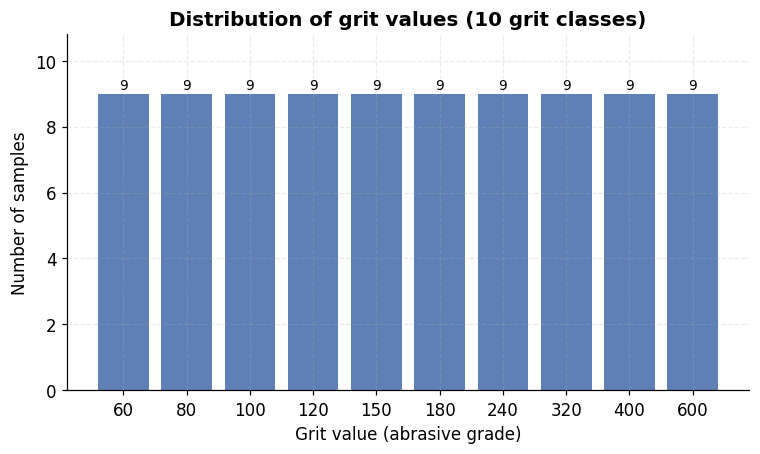

Grit_Utilise
60     9
80     9
100    9
120    9
150    9
180    9
240    9
320    9
400    9
600    9
Name: count, dtype: int64

In [5]:
grit_counts = df["Grit_Utilise"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(grit_counts.index.astype(str), grit_counts.values, color="#4C72B0", alpha=0.9)
for x, v in zip(grit_counts.index.astype(str), grit_counts.values):
    ax.text(x, v + 0.05, str(v), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Grit value (abrasive grade)")
ax.set_ylabel("Number of samples")
ax.set_title(f"Distribution of grit values ({len(grit_counts)} grit classes)")
ax.set_ylim(0, grit_counts.max() * 1.2)
plt.show()

grit_counts

### Ra distribution

`Ra_Moyenne` is the mean arithmetic roughness (µm) — the continuous quantity we
bin into classes. The histogram below, with descriptive statistics, shows a
right-skewed spread from sub-micron (smooth) up to ~1.85 µm (rough).

count    90.000
mean      0.848
std       0.358
min       0.387
25%       0.593
50%       0.771
75%       1.069
max       1.850


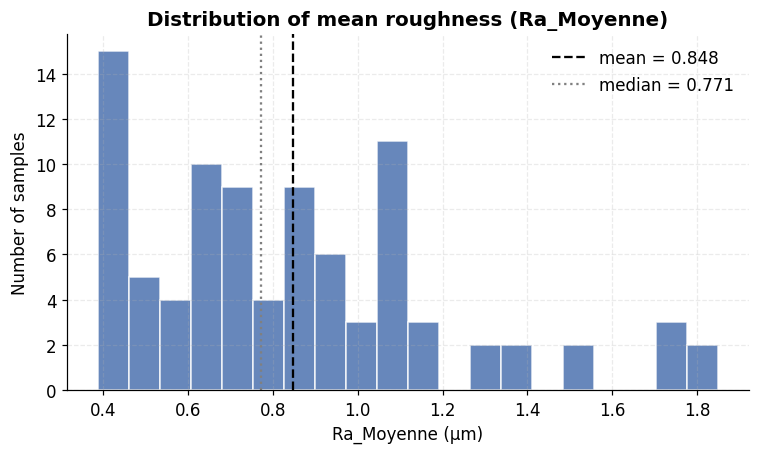

In [6]:
print(df["Ra_Moyenne"].describe().round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(df["Ra_Moyenne"], bins=20, color="#4C72B0", alpha=0.85, edgecolor="white")
ax.axvline(df["Ra_Moyenne"].mean(), color="black", ls="--", lw=1.5,
           label=f"mean = {df['Ra_Moyenne'].mean():.3f}")
ax.axvline(df["Ra_Moyenne"].median(), color="grey", ls=":", lw=1.5,
           label=f"median = {df['Ra_Moyenne'].median():.3f}")
ax.set_xlabel("Ra_Moyenne (µm)")
ax.set_ylabel("Number of samples")
ax.set_title("Distribution of mean roughness (Ra_Moyenne)")
ax.legend()
plt.show()

## 3. From Ra to classes

The continuous Ra is converted into three classes by cutting at the **33rd and
67th percentiles** of the data. Those cut points are stored in the project as
`RA_THRESHOLDS`. Because the thresholds are percentiles, the three classes come
out essentially balanced — which is exactly what we want for training.

| Class | Rule (Ra in µm) |
|-------|-----------------|
| Smooth | `Ra < 0.653` |
| Medium | `0.653 ≤ Ra < 0.960` |
| Rough  | `Ra ≥ 0.960` |

Project thresholds  : 0.653, 0.960 µm
Empirical 33/67 pct : 0.653, 0.960 µm  (they match by design)


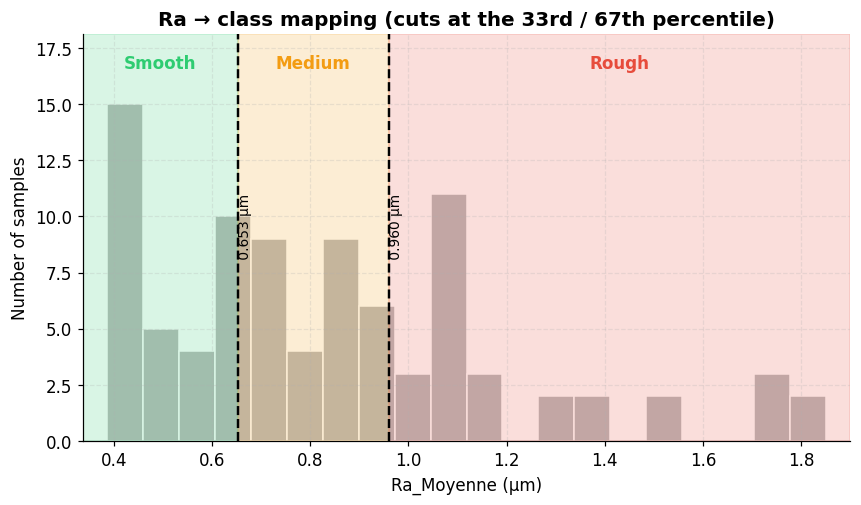

In [7]:
lo, hi = RA_THRESHOLDS
emp = np.percentile(df["Ra_Moyenne"], [33, 67])
print(f"Project thresholds  : {lo:.3f}, {hi:.3f} µm")
print(f"Empirical 33/67 pct : {emp[0]:.3f}, {emp[1]:.3f} µm  (they match by design)")

fig, ax = plt.subplots(figsize=(9, 4.8))
counts, _, _ = ax.hist(df["Ra_Moyenne"], bins=20, color="#bbbbbb", edgecolor="white")
ymax = counts.max() * 1.15
xmin = df["Ra_Moyenne"].min() - 0.05
xmax = df["Ra_Moyenne"].max() + 0.05

# Shade the three class regions.
ax.axvspan(xmin, lo, color=CLASS_COLORS["Smooth"], alpha=0.18)
ax.axvspan(lo, hi, color=CLASS_COLORS["Medium"], alpha=0.18)
ax.axvspan(hi, xmax, color=CLASS_COLORS["Rough"], alpha=0.18)
for t in (lo, hi):
    ax.axvline(t, color="black", ls="--", lw=1.6)
    ax.text(t, ymax * 0.55, f" {t:.3f} µm", rotation=90, va="center", fontsize=9)

ax.text((xmin + lo) / 2, ymax, "Smooth", ha="center", va="top",
        color=CLASS_COLORS["Smooth"], fontweight="bold")
ax.text((lo + hi) / 2, ymax, "Medium", ha="center", va="top",
        color=CLASS_COLORS["Medium"], fontweight="bold")
ax.text((hi + xmax) / 2, ymax, "Rough", ha="center", va="top",
        color=CLASS_COLORS["Rough"], fontweight="bold")

ax.set_xlim(xmin, xmax)
ax.set_ylim(0, ymax * 1.05)
ax.set_xlabel("Ra_Moyenne (µm)")
ax.set_ylabel("Number of samples")
ax.set_title("Ra → class mapping (cuts at the 33rd / 67th percentile)")
plt.show()

### Class balance

Because the thresholds are percentiles, the classes are (near-)perfectly
balanced. Balanced classes mean accuracy is a meaningful metric and no
class-reweighting is needed.

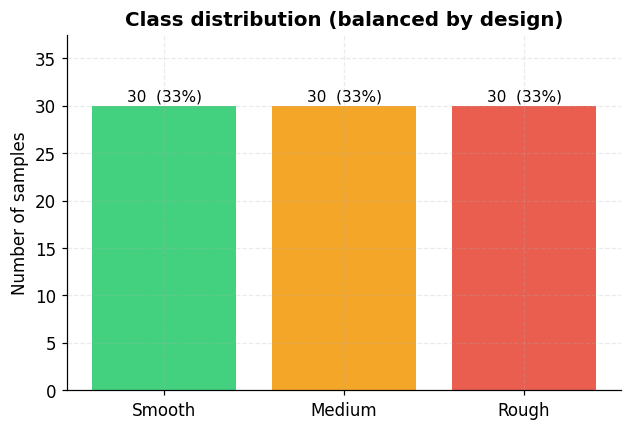

class
Smooth    30
Medium    30
Rough     30
Name: count, dtype: int64

In [8]:
class_counts = df["class"].value_counts().reindex(CLASSES)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
bars = ax.bar(CLASSES, class_counts.values,
              color=[CLASS_COLORS[c] for c in CLASSES], alpha=0.9)
for b, v in zip(bars, class_counts.values):
    pct = 100 * v / class_counts.sum()
    ax.text(b.get_x() + b.get_width() / 2, v + 0.2, f"{v}  ({pct:.0f}%)",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution (balanced by design)")
ax.set_ylim(0, class_counts.max() * 1.25)
plt.show()

class_counts

## 4. Sample images per class

Three example surfaces per class (one image per sample for variety), annotated
with their Ra and grit values. Visually, roughness increases from the fine,
uniform Smooth surfaces to the coarse, high-contrast Rough ones. Images are
shown downsampled for display.

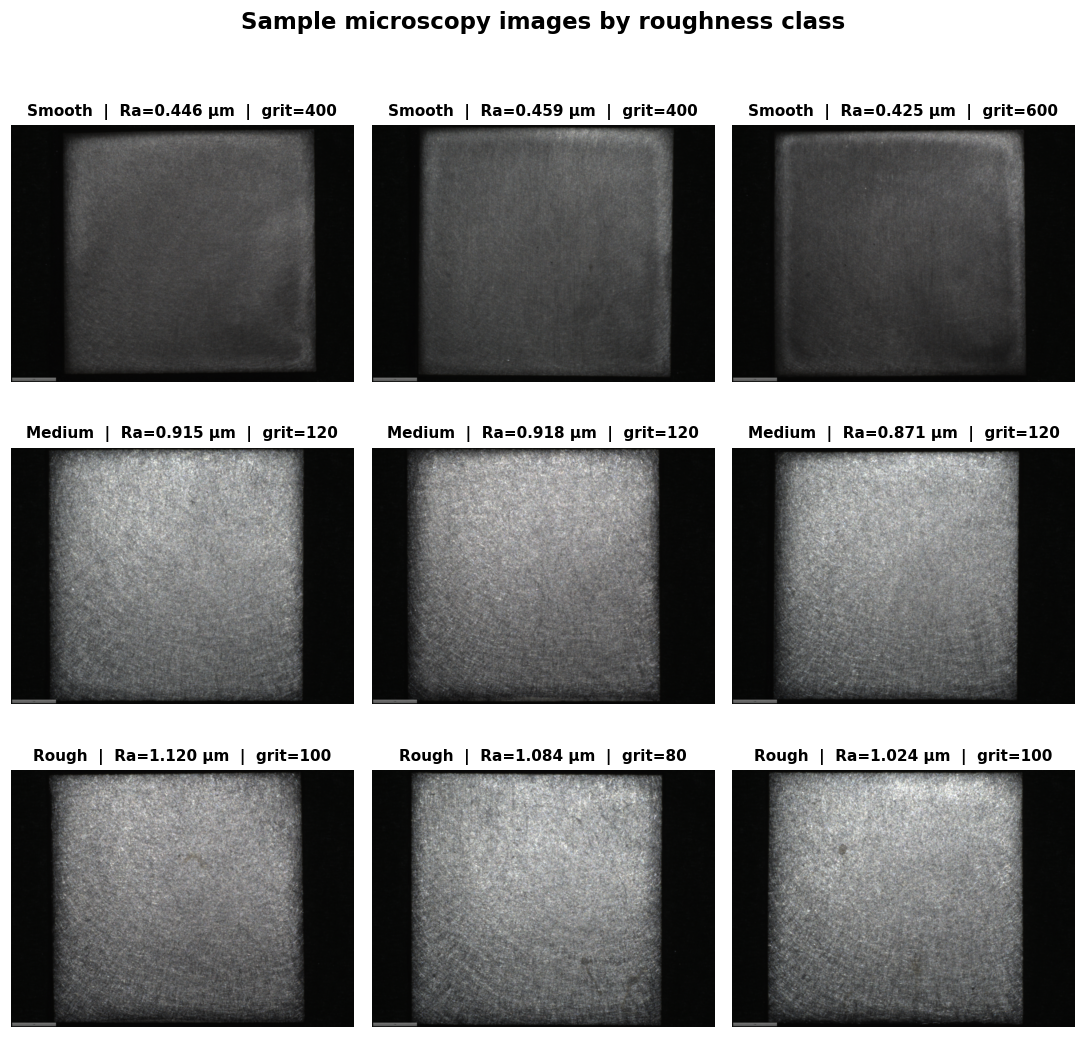

In [9]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for row, cls in enumerate(CLASSES):
    subset = img_df[img_df["class"] == cls]
    groups = rng.choice(subset["group_id"].unique(),
                        size=min(3, subset["group_id"].nunique()), replace=False)
    for col, gid in enumerate(groups):
        rec = subset[subset["group_id"] == gid].iloc[0]
        img = Image.open(rec["image_path"]).convert("RGB")
        img.thumbnail((600, 600))  # downsample for fast, light display
        ax = axes[row, col]
        ax.imshow(img)
        ax.set_title(f"{cls}  |  Ra={rec['ra']:.3f} µm  |  grit={rec['grit']}",
                     fontsize=10)
        ax.axis("off")

fig.suptitle("Sample microscopy images by roughness class",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 5. Image statistics: brightness & contrast

Beyond eyeballing, simple grayscale statistics show the classes differ
measurably. We use **brightness** (mean pixel value) and **contrast** (pixel
standard deviation) on a 0–255 scale. For speed we use one representative image
per sample (the first angle); the per-class trends are the same across angles.

In [10]:
def image_stats(path, max_side=512):
    """Grayscale mean (brightness) and std (contrast), 0-255."""
    im = Image.open(path).convert("L")
    im.thumbnail((max_side, max_side))  # keep array ops light
    arr = np.asarray(im, dtype=np.float32)
    return float(arr.mean()), float(arr.std())


sample_imgs = img_df[img_df["angle"] == 1].copy()  # one image per sample
stats = sample_imgs["image_path"].apply(image_stats)
sample_imgs["brightness"] = [s[0] for s in stats]
sample_imgs["contrast"] = [s[1] for s in stats]

summary = (sample_imgs.groupby("class")[["brightness", "contrast"]]
           .agg(["mean", "std"]).reindex(CLASSES).round(2))
summary

brightness        contrast      
             mean    std     mean   std
class                                  
Smooth      60.58  11.22    39.62  8.28
Medium      77.30   7.78    52.17  6.00
Rough       88.02   5.41    61.73  4.10

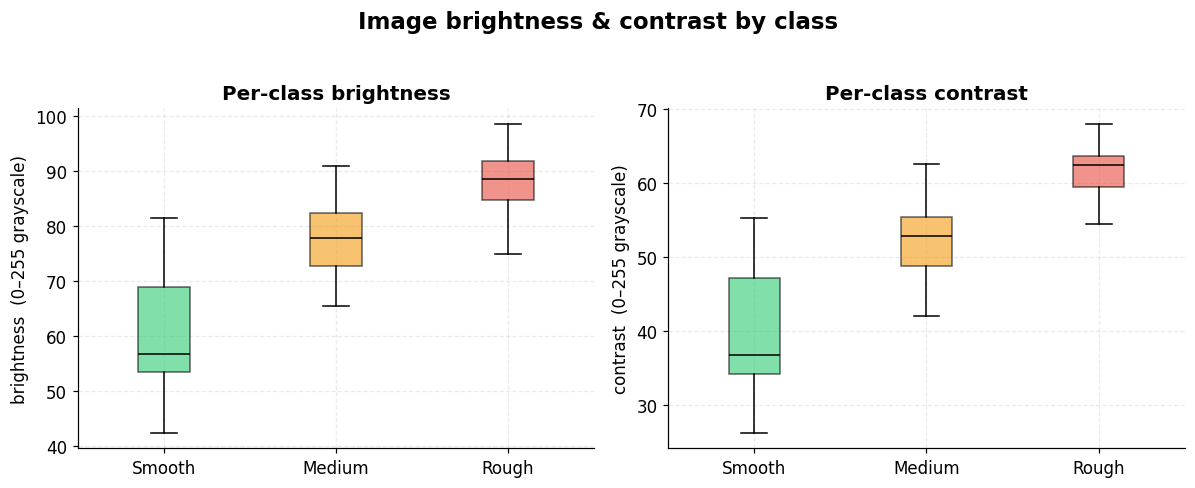

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, metric in zip(axes, ["brightness", "contrast"]):
    data = [sample_imgs.loc[sample_imgs["class"] == c, metric].values for c in CLASSES]
    bp = ax.boxplot(data, tick_labels=CLASSES, patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], CLASSES):
        patch.set_facecolor(CLASS_COLORS[c])
        patch.set_alpha(0.6)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(f"Per-class {metric}")
    ax.set_ylabel(f"{metric}  (0–255 grayscale)")

fig.suptitle("Image brightness & contrast by class", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 6. Takeaways

- **Balanced, modest-sized dataset:** 90 physical samples × 4 angles = 360
  images, evenly spread over 10 grit grades and 3 roughness classes (30 samples
  each). The small size is why the project leans on transfer learning, heavy
  augmentation, and cross-validation.
- **Labels are percentile-based:** the Smooth/Medium/Rough cuts sit at the 33rd
  and 67th Ra percentiles (0.653 / 0.960 µm), giving balanced classes.
- **Grit matters:** the same visual texture can map to different roughness
  depending on the abrasive, which is why every model is conditioned on the grit
  value rather than the image alone.
- **Texture is learnable:** brightness and especially contrast trend with the
  roughness class, confirming the visual signal the CNN/ViT backbones exploit.
  The hardest boundary is Smooth vs Medium, which matches the model error
  analysis in the project's benchmarks.